In [1]:

from pipeline_pre_ADI.pre_process.pre_processing import *
from pipeline_pre_ADI.pre_process.plot_pre_processing import *

#org
import shutil 
import torch
import numpy as np
import warnings
import os, re, glob
from scipy import interpolate
import pandas as pd
from copy import deepcopy
from collections import Counter


#images
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import tifffile as tiff
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.ndimage import center_of_mass
from photutils.aperture import CircularAperture
plt.close('all')


#scientific libraries
from applefy.utils import flux_ratio2mag, mag2flux_ratio
from applefy.utils.photometry import AperturePhotometryMode
from applefy.detections.contrast import Contrast
from applefy.utils.photometry import AperturePhotometryMode
from applefy.statistics import TTest, gaussian_sigma_2_fpf, LaplaceBootstrapTest
from applefy.utils.positions import center_subpixel

from pathlib import Path
root_dir = Path(".")
print(root_dir)

/home/aosimul/noah/env_hci/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


.


## File control

In [2]:
source = Path('/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_05')
destination =Path('/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_05_bad_pred')

destination.mkdir(parents=True, exist_ok=True)

for f in source.iterdir():
    if f.is_file() and "pred" in f.name:
        new_name = f.name.replace("pred", "bad_pred")
        f.rename(destination / new_name)
    if f.is_file() and "int" in f.name:
        new_name = f.name.replace("int", "pred")
        f.rename(f.with_name(new_name))

## Try centering methods

In [2]:

import numpy as np
from pathlib import Path
import warnings
import os, glob
from multiprocessing import cpu_count
import importlib
import time
import gc
import pandas as pd
from typing import Optional, Tuple, Sequence
import pickle 

# scientific libraries
from sklearn.decomposition import PCA
from photutils.centroids import centroid_com
from photutils.aperture import aperture_photometry, CircularAperture
from scipy import interpolate
from scipy.ndimage import center_of_mass as nd_center_of_mass
from scipy.ndimage import gaussian_filter, shift, map_coordinates, fourier_shift
from skimage.registration import phase_cross_correlation
from applefy.utils.positions import center_subpixel
from numpy.fft import fftn, ifftn
from scipy.optimize import curve_fit
from scipy import ndimage as ndi
from scipy import signal

# images
import matplotlib as mpl
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
mpl.rcParams["hatch.linewidth"] = 0.5  # previous pdf hatch linewidth
import tifffile as tiff
from matplotlib.patches import Circle
from photutils.aperture import CircularAperture


# import utils.plot_pre_processing as plot
# importlib.reload(plot)
# from utils.plot_pre_processing import *

In [2]:
save_path = '/home/aosimul/noah/data/ghost_images/10_20ws/'

with open(f'{save_path}RC_coef.pkl', 'rb') as f:
    raw_contrast_amplitudes = pickle.load(f)

In [4]:
raw_contrast_amplitudes.keys()

dict_keys(['int_0.5ro_10ws', 'int_0.5ro_20ws', 'int_0.7ro_10ws', 'int_0.7ro_20ws', 'int_1.0ro_10ws', 'int_1.0ro_20ws', 'pred_0.5ro_10ws', 'pred_0.5ro_20ws', 'pred_0.7ro_10ws', 'pred_0.7ro_20ws', 'pred_1.0ro_10ws', 'pred_1.0ro_20ws'])

In [5]:
if 'int_0.5ro_10ws' in raw_contrast_amplitudes.keys():
    print('lol')

lol


In [ ]:

x = [1,2,3]
y = [2,5,7]

raw_contrast = pd.DataFrame(
        {
            #"separation_FWHM": x,
            "raw_contrast": y,
        },
        index= x,
    )
plt.plot(raw_contrast.index *2,
            raw_contrast["raw_contrast"],)

In [4]:

path = "/home/aosimul/noah/data/ghost_images/10_20ws_2/raw_contrast.h5"

with pd.HDFStore(path, mode="a") as store:
    keys = store.keys()

    for old_key in keys:
        # Find the number after "bad_pred_"
        match = re.search(r"pred_([0-9]*\.?[0-9]+)ro", old_key)

        if match:
            old_value = float(match.group(1))
            new_value = old_value * 10

            # Avoid unnecessary ".0", e.g. 5.0 -> 5
            new_value = int(new_value) if new_value.is_integer() else new_value

            new_key = old_key.replace(
                f"pred_{match.group(1)}ro",
                f"pred_{new_value}ro"
            )

            print(f"{old_key} -> {new_key}")

            store.put(new_key, store[old_key])
            store.remove(old_key)

/pred_0.5ro_10ws_3 -> /pred_5ro_10ws_3
/pred_0.5ro_20ws_3 -> /pred_5ro_20ws_3
/pred_0.7ro_10ws_3 -> /pred_7ro_10ws_3
/pred_0.7ro_20ws_3 -> /pred_7ro_20ws_3
/pred_1.0ro_10ws_3 -> /pred_10ro_10ws_3
/pred_1.0ro_20ws_3 -> /pred_10ro_20ws_3
/psf_pred_0.5ro_10ws_1 -> /psf_pred_5ro_10ws_1
/psf_pred_0.5ro_10ws_2 -> /psf_pred_5ro_10ws_2
/psf_pred_0.5ro_20ws_1 -> /psf_pred_5ro_20ws_1
/psf_pred_0.5ro_20ws_2 -> /psf_pred_5ro_20ws_2
/psf_pred_0.7ro_10ws_1 -> /psf_pred_7ro_10ws_1
/psf_pred_0.7ro_10ws_2 -> /psf_pred_7ro_10ws_2
/psf_pred_0.7ro_20ws_1 -> /psf_pred_7ro_20ws_1
/psf_pred_0.7ro_20ws_2 -> /psf_pred_7ro_20ws_2
/psf_pred_1.0ro_10ws_1 -> /psf_pred_10ro_10ws_1
/psf_pred_1.0ro_10ws_2 -> /psf_pred_10ro_10ws_2
/psf_pred_1.0ro_20ws_1 -> /psf_pred_10ro_20ws_1
/psf_pred_1.0ro_20ws_2 -> /psf_pred_10ro_20ws_2


['/pred_10ro_10ws_3', '/pred_10ro_20ws_3', '/pred_5ro_10ws_3', '/pred_5ro_20ws_3', '/pred_7ro_10ws_3', '/pred_7ro_20ws_3', '/psf_pred_10ro_10ws_1', '/psf_pred_10ro_10ws_2', '/psf_pred_10ro_20ws_1', '/psf_pred_10ro_20ws_2', '/psf_pred_5ro_10ws_1', '/psf_pred_5ro_10ws_2', '/psf_pred_5ro_20ws_1', '/psf_pred_5ro_20ws_2', '/psf_pred_7ro_10ws_1', '/psf_pred_7ro_10ws_2', '/psf_pred_7ro_20ws_1', '/psf_pred_7ro_20ws_2']


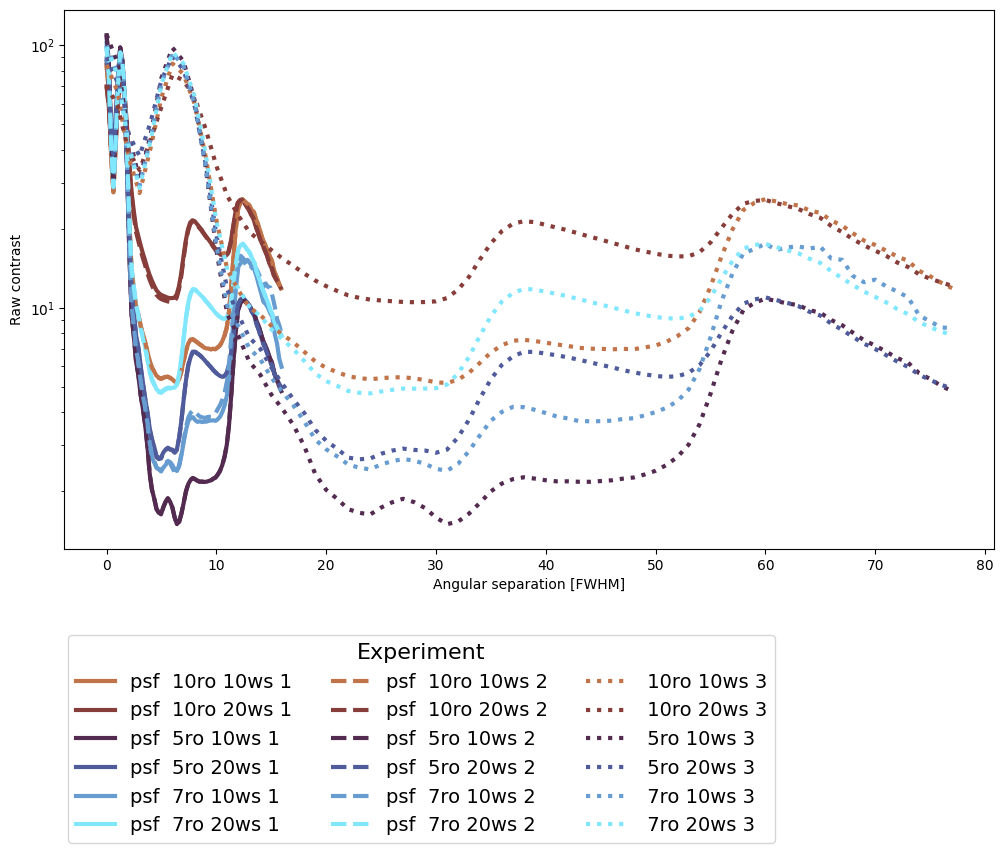

In [5]:
with pd.HDFStore(f"/home/aosimul/noah/data/ghost_images/10_20ws_2/raw_contrast.h5") as store:
    fig, ax = plt.subplots(figsize=(12, 7))
    gs0 = fig.add_gridspec(1, 1)
    # color_map = plt.cm.get_cmap('inferno')   # seaborn-style colormap available in mpl
    # colors = [color_map(int(i)) for i in np.round(np.linspace(0, 250, len(store.keys())))]
    color_map = plt.colormaps["tab20c"]
    colors = color_map(np.linspace(0, 1, len(store)))
    seq = 'managua'
    reds = plt.colormaps[seq]
    blues = plt.colormaps[seq]
    greens = plt.colormaps[seq]

    int_keys = [k for k in store.keys() if k.endswith("1")]
    pred_keys = [k for k in store.keys() if k.endswith("2")]
    pred__keys = [k for k in store.keys() if k.endswith("3")]

    red_colors = dict(zip(int_keys, reds(np.linspace(0.2, 1, len(int_keys)))))
    blue_colors = dict(zip(pred_keys, blues(np.linspace(0.2, 1, len(pred_keys)))))
    greens_colors = dict(zip(pred__keys, greens(np.linspace(0.2, 1, len(pred__keys)))))

    # Then inside the loop:

    ordered_keys = int_keys + pred_keys + pred__keys

    for key in ordered_keys:
        df = store[key]

        line_color = (
            red_colors[key] if key.endswith("1")
            else blue_colors[key] if key.endswith("2")
            else greens_colors[key] 
        )

        mark = (
            '-'  if key.endswith("1")
            else '--' if key.endswith("2")
            else ':'
        )    

        label =   key.strip("/").replace('_', ' ').replace('windspeed', ' ws').replace('r0', 'e-1 r0,').replace('pred', '')  
        ax.semilogy(
            df.index.get_level_values('pixel_rad_fwhm'),
            df["raw_contrast"],
            lw=3,
            color = line_color, #colors[i],
            ls = mark,
            label= label,
        )

    leg1 = fig.legend(
        fontsize=14,
        loc="lower left",
        bbox_to_anchor=(0.12, -(0.018 * len(store.keys()))),
        ncol=3,
        title="Experiment",
        title_fontsize=16, 
    )
    ax.set_xlabel("Angular separation [FWHM]")
    ax.set_ylabel("Raw contrast")
    print(store.keys())

### Alignment

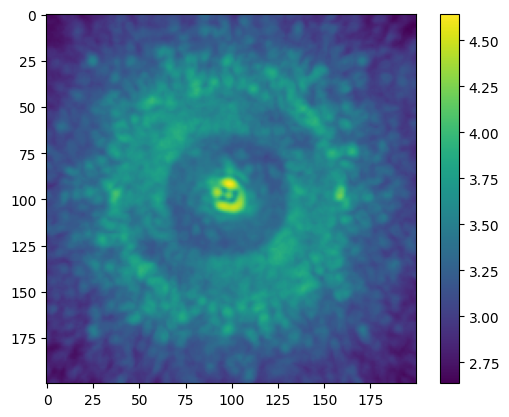

In [22]:
img_file = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/pred_1.0ro_20ws_coro_'
sci_img = tiff.imread(glob.glob(f"{img_file}*.tif"), 
                          key=range(6667)
                          )
 
reference = np.median(sci_img, axis=0)
plt.imshow(np.log10(reference))
plt.colorbar()

In [23]:
upsample_factor: int = 100
dtype=np.float32
aligned = np.empty_like(sci_img, dtype=dtype)

ref_fft = fftn(reference)

for i, image in enumerate(sci_img):

    shift_estimate, _, _ = (
        phase_cross_correlation(
            reference,
            image,
            upsample_factor=upsample_factor, #consider on ROI only
        )
    )
    print(shift_estimate)
    image_fft = fftn(image)
    shifted = ifftn(fourier_shift(image_fft, shift_estimate)).real
    aligned[i] = shifted.astype(dtype)

[-0.05  0.06]
[0.01 0.02]
[-0.01  0.03]
[-0.04  0.01]
[ 0.04 -0.01]
[-0.02 -0.02]
[0.01 0.02]
[-0.05  0.  ]
[-0.01 -0.02]
[ 0.01 -0.03]
[-0.01  0.06]
[-0.06 -0.01]
[0.   0.03]
[-0.05  0.  ]
[-0.03 -0.01]
[-0.01  0.05]
[ 0.01 -0.01]
[-0.09 -0.02]
[-0.03 -0.02]
[0.02 0.  ]
[-0.05 -0.01]
[-0.04 -0.03]
[-0.03  0.01]
[ 0.02 -0.02]
[-0.02 -0.06]
[-0.01  0.07]
[-0.08 -0.02]
[ 0.02 -0.02]
[-0.03 -0.02]
[-0.02 -0.04]
[0.01 0.05]
[ 0.04 -0.04]
[0.02 0.05]
[0.03 0.02]
[-0.01 -0.05]
[ 0.04 -0.01]
[-0.01 -0.03]
[-0.06 -0.06]
[-0.03  0.04]
[-0.13  0.  ]
[-0.02 -0.08]
[-0.03 -0.02]
[-0.02 -0.07]
[-0.06 -0.02]
[-0.03 -0.06]
[0.02 0.  ]
[-0.04 -0.09]
[-0.07 -0.04]
[-0.02 -0.06]
[-0.05 -0.01]
[0. 0.]
[-0.02 -0.03]
[-0.09 -0.12]
[ 0.01 -0.05]
[ 0.02 -0.12]
[-0.12 -0.11]
[-0.05 -0.04]
[0. 0.]
[-0.06 -0.05]
[-0.03  0.01]
[-0.07 -0.03]
[-0.02  0.  ]
[ 0.01 -0.01]
[-0.11 -0.06]
[-0.01 -0.03]
[ 0.   -0.01]
[-0.01  0.03]
[-0.06 -0.02]
[-0.05 -0.02]
[-0.06  0.  ]


[-0.11 -0.02]
[0.   0.03]
[-0.09 -0.04]
[-0.04 -0.03]
[-0.03 -0.09]
[-0.05  0.04]
[-0.03 -0.06]
[-0.03  0.02]
[-0.01  0.04]
[-0.06  0.03]
[-0.04  0.05]
[-0.07 -0.04]
[-0.06 -0.02]
[-0.03  0.01]
[-0.04  0.09]
[-0.03 -0.04]
[0.01 0.08]
[-0.13  0.03]
[-0.17  0.  ]
[-0.01  0.05]
[-0.04  0.03]
[0.   0.07]
[-0.08  0.06]
[-0.06 -0.01]
[-0.08  0.1 ]
[-0.05  0.02]
[-0.04  0.05]
[-0.03  0.05]
[-0.05  0.02]
[-0.06 -0.01]
[-0.03  0.02]
[-0.04  0.04]
[ 0.01 -0.03]
[ 0.04 -0.02]
[0.   0.03]
[0.07 0.01]
[ 0.04 -0.03]
[0.02 0.01]
[0.03 0.1 ]
[ 0.05 -0.05]
[0.   0.04]
[-0.01  0.02]
[-0.01  0.05]
[0.05 0.04]
[0.07 0.  ]
[0.01 0.01]
[0.07 0.03]
[ 0.09 -0.02]
[ 0.07 -0.06]
[ 0.04 -0.02]
[ 0.04 -0.06]
[0.03 0.  ]
[-0.01  0.  ]
[ 0.09 -0.05]
[0.06 0.01]
[ 0.02 -0.05]
[ 0.09 -0.05]
[-0.01 -0.03]
[-0.06 -0.03]
[ 0.01 -0.02]
[ 0.08 -0.08]
[-0.01 -0.05]
[ 0.01 -0.08]
[-0.01  0.01]
[ 0.05 -0.05]
[-0.03  0.  ]
[ 0.02 -0.07]
[ 0.03 -0.04]
[-0.02 -0.07]
[-0.02 -0.02]
[0.02 0.01]
[ 0.02 -0.02]
[0.04 0.03]
[ 0.02 -0.

/tmp/ipykernel_267364/252142783.py:16: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(align_change))


Text(0.5, 1.0, 'Difference')

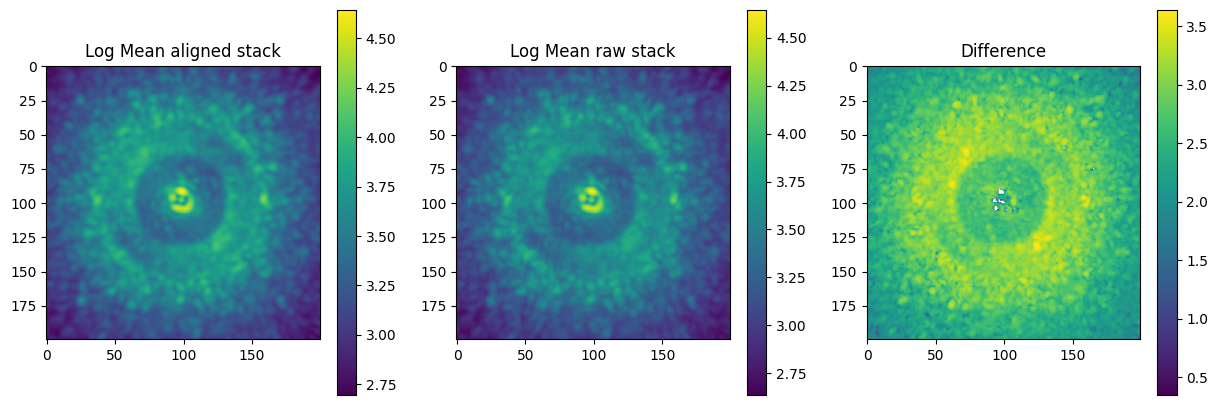

In [24]:
align_ref = np.mean(aligned, axis = 0)
align_change = align_ref - reference

plt.figure(figsize = (15,5))
plt.subplot(1,3,1)
plt.imshow(np.log10(align_ref))
plt.colorbar()
plt.title('Log Mean aligned stack')

plt.subplot(1,3,2)
plt.imshow(np.log10(reference))
plt.colorbar()
plt.title('Log Mean raw stack')

plt.subplot(1,3,3)
plt.imshow(np.log10(align_change))
plt.colorbar()
plt.title('Difference')

### Estimate center

In [25]:
stack = np.asarray(aligned)
if stack.ndim != 3:
    raise ValueError("stack must be a 3D array with shape (N, ny, nx)")


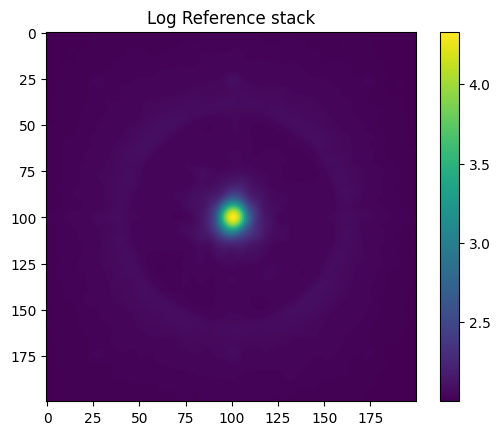

In [26]:
coords= None
normalisation = True
search_radius=7
smooth_sigma=2
upsample_factor=100
max_iter=100
tol=1e-2
eps = 1e-9

method='masked_annulus'
radius = 55
ny, nx = stack.shape[1], stack.shape[2]
method = method.lower().strip()
ref = reference_stack = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_05/pred_1.0ro_10ws_no_coro_2026-08-05T13-23-09.96'

def _prepare_ref(ref):
    if ref is None:
        return None
    if isinstance(ref, str):
        if tiff is None:
            raise RuntimeError("tifffile required to load reference_stack from a path string")
        files = glob.glob(f"{ref}*.tif")
        if len(files) == 0:
            raise FileNotFoundError(f"No files matching '{ref}*.tif'")
        ref_arr = tiff.imread(files)
        ref_m = np.median(ref_arr, axis=0)
    else:
        ref_arr = np.asarray(ref)
        ref_m = np.median(ref_arr, axis=0) if ref_arr.ndim == 3 else ref_arr
    return gaussian_filter(ref_m, smooth_sigma) if (smooth_sigma and smooth_sigma > 0) else ref_m

ref_psf = _prepare_ref(reference_stack)

if ref_psf is not None:

    plt.imshow(np.log10(ref_psf))
    plt.colorbar()
    plt.title('Log Reference stack')

/tmp/ipykernel_267364/682589912.py:43: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(bw))
/tmp/ipykernel_267364/682589912.py:48: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(mask))
/tmp/ipykernel_267364/682589912.py:53: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(eroded))
/tmp/ipykernel_267364/682589912.py:58: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(boundary))


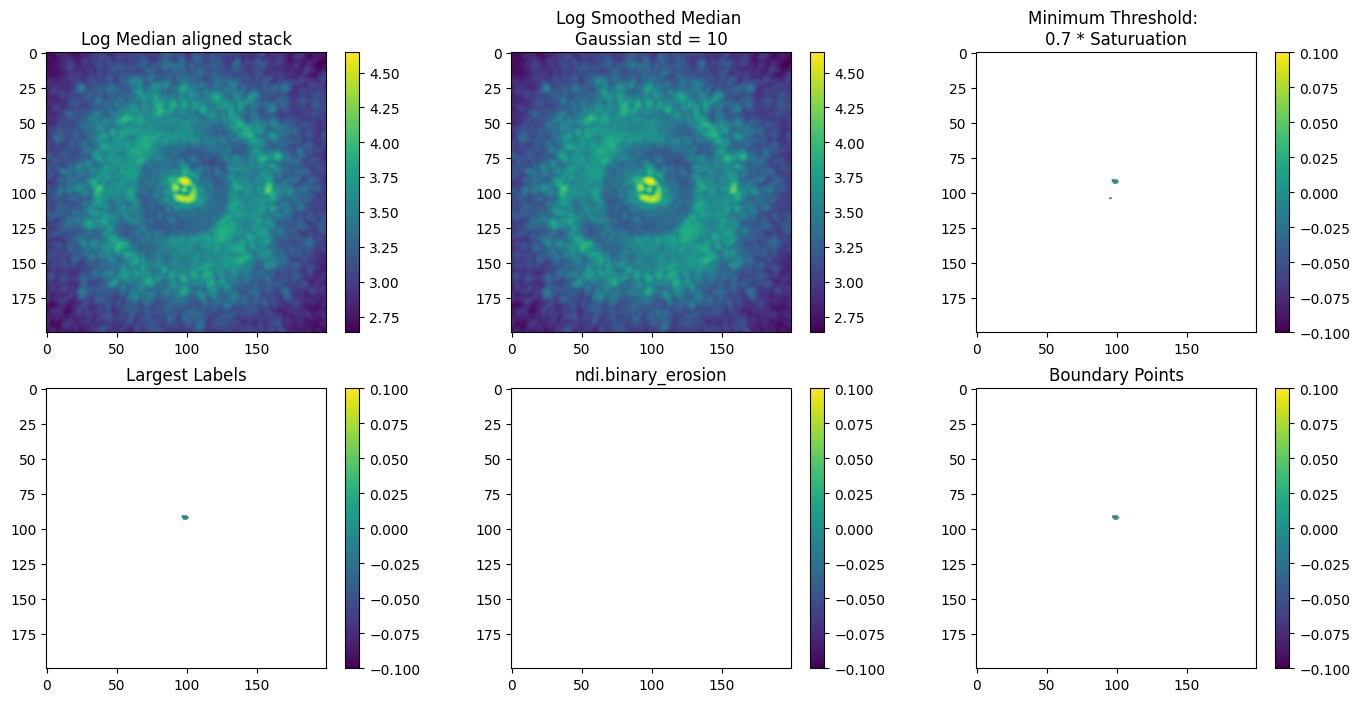

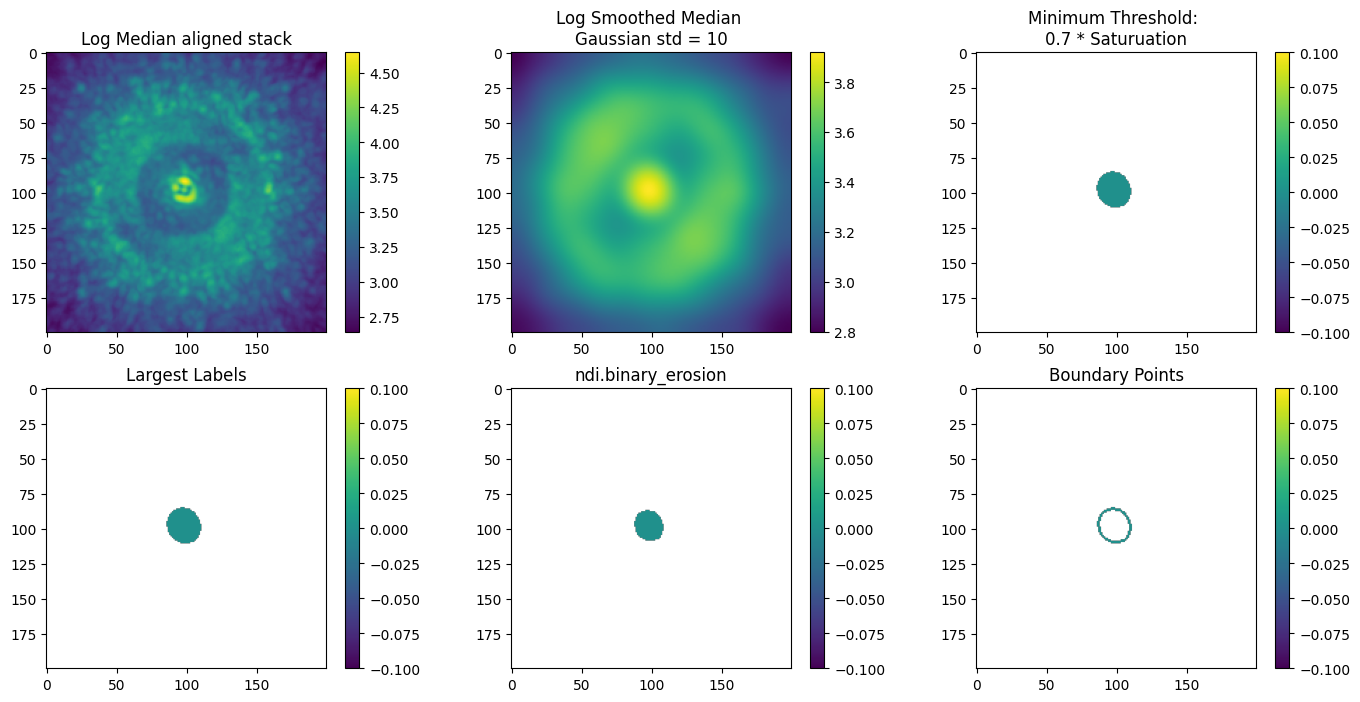

In [28]:
im = np.median(stack, axis = 0)
im = np.asarray(im, dtype=float)

im_s = gaussian_filter(im, 10)
threshold_frac = 0.7

def masking(im_s):
    thr = np.max(im_s) * threshold_frac
    bw = im_s > thr

    # keep largest connected component (assumed to be the occulting mask)
    labeled, nl = ndi.label(bw)
    if nl == 0:
        raise RuntimeError("No dark region found for coronagraph mask detection.")
    sizes = ndi.sum(bw, labeled, range(1, nl+1))
    if sizes.size == 0:
        raise RuntimeError("No components found.")
    largest_label = np.argmax(sizes) + 1
    mask = (labeled == largest_label)
    # if mask.sum() > max_area:
    #     raise RuntimeError("Detected mask too large / noisy detection.")

    # boundary points
    eroded = ndi.binary_erosion(mask, iterations=2)
    boundary = mask ^ eroded
    ys, xs = np.nonzero(boundary)
    if len(xs) < 10:
        # fallback to full mask points
        ys, xs = np.nonzero(mask)

    plt.figure(figsize = (17,8))
    plt.subplot(2,3,1)
    plt.imshow(np.log10(im))
    plt.colorbar()
    plt.title('Log Median aligned stack')

    plt.subplot(2,3,2)
    plt.imshow(np.log10(im_s))
    plt.colorbar()
    plt.title('Log Smoothed Median \nGaussian std = 10')

    plt.subplot(2,3,3)
    plt.imshow(np.log10(bw))
    plt.colorbar()
    plt.title(f'Minimum Threshold: \n{threshold_frac} * Saturuation')

    plt.subplot(2,3,4)
    plt.imshow(np.log10(mask))
    plt.colorbar()
    plt.title('Largest Labels')

    plt.subplot(2,3,5)
    plt.imshow(np.log10(eroded))
    plt.colorbar()
    plt.title('ndi.binary_erosion')

    plt.subplot(2,3,6)
    plt.imshow(np.log10(boundary))
    plt.colorbar()
    plt.title('Boundary Points')

    return xs, ys

xs, ys = masking(im)
xs_s, ys_s = masking(im_s)

In [11]:
def _algebraic_circle_fit(xs: np.ndarray, ys: np.ndarray) -> Tuple[float,float,float]:
    """
    Algebraic least-squares circle fit.
    Returns (yc, xc, r)
    """
    A = np.column_stack([xs, ys, np.ones_like(xs)])
    b = xs**2 + ys**2
    c, *_ = np.linalg.lstsq(A, b, rcond=None)
    a1, a2, c0 = c
    xc = 0.5 * a1
    yc = 0.5 * a2
    r = np.sqrt(xc**2 + yc**2 + c0)
    return yc, xc, r

yc, xc, r = _algebraic_circle_fit(xs_s.astype(float), ys_s.astype(float))

print('With Smoothing: ', yc, xc)




With Smoothing:  96.5562767494751 97.85715362114792


/tmp/ipykernel_1202653/3234204228.py:6: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(cx, cy, 8, 'red', '.')
/tmp/ipykernel_1202653/3234204228.py:7: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(cx, cy, 700, 'red', 'o', alpha = 0.3)


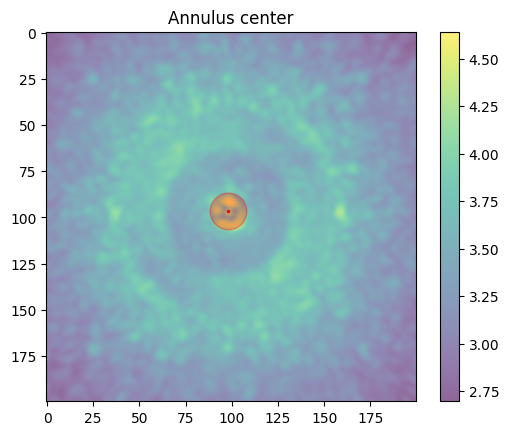

In [12]:
cy, cx = float(yc), float(xc)

plt.imshow(np.log10(align_ref), alpha = 0.6)
plt.colorbar()
plt.title('Annulus center')
plt.scatter(cx, cy, 8, 'red', '.')
plt.scatter(cx, cy, 700, 'red', 'o', alpha = 0.3)

### Crop Stack

In [16]:
ny, nx = aligned.shape[1:]


center_y = int(np.floor(float(cy) + 0.5))
center_x = int(np.floor(float(cx) + 0.5))

# Shift required to move (cy, cx) -> (target_y, target_x)
dy = center_y - cy
dx = center_x - cx

aligned_shifted = shift(
    aligned,
    shift=(0, dy, dx),
    order=3,
    mode="constant",
    cval=0,
)

if radius is None:
    half = int(min(center_y, center_x, ny - 1 - center_y, nx - 1 - center_x))
else:
    half = int(radius)


97.85715362114792 96.5562767494751
98 97
55.0 55.0


/tmp/ipykernel_1202653/2992780266.py:22: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(sub_center_x, sub_center_y, 8, 'red', '.')
/tmp/ipykernel_1202653/2992780266.py:23: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(sub_center_x, sub_center_y, 1500, 'red', 'o', alpha = 0.3)
/tmp/ipykernel_1202653/2992780266.py:29: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(sub_center_x_shifted, sub_center_y_shifted, 8, 'red', '.')
/tmp/ipykernel_1202653/2992780266.py:30: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; t

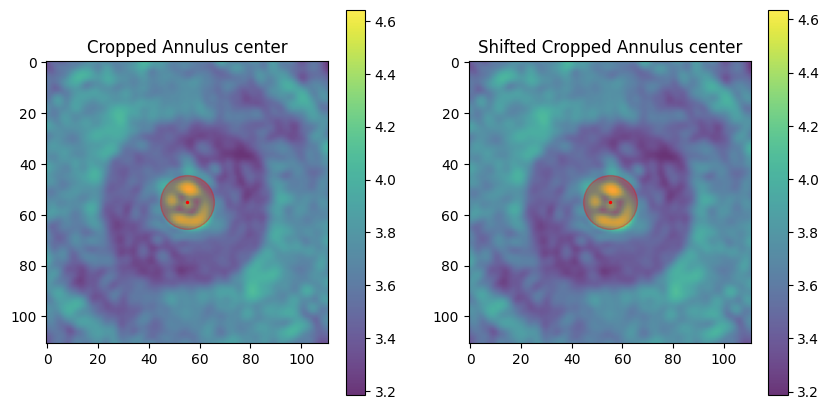

In [17]:
cropped = aligned[
    :,
    center_y - half : center_y + half + 1,
    center_x - half : center_x + half + 1
]
crop_ref = np.mean(cropped, axis = 0)
sub_center_x, sub_center_y = center_subpixel(crop_ref)

cropped_shifted = aligned_shifted[
    :,
    center_y - half : center_y + half + 1,
    center_x - half : center_x + half + 1
]
crop_ref_shifted = np.mean(cropped_shifted, axis = 0)
sub_center_x_shifted, sub_center_y_shifted = center_subpixel(crop_ref_shifted)

plt.figure(figsize = (10,5))
plt.subplot(121)
plt.imshow(np.log10(crop_ref), alpha = 0.8)
plt.colorbar()
plt.title('Cropped Annulus center')
plt.scatter(sub_center_x, sub_center_y, 8, 'red', '.')
plt.scatter(sub_center_x, sub_center_y, 1500, 'red', 'o', alpha = 0.3)

plt.subplot(122)
plt.imshow(np.log10(crop_ref_shifted), alpha = 0.8)
plt.colorbar()
plt.title('Shifted Cropped Annulus center')
plt.scatter(sub_center_x_shifted, sub_center_y_shifted, 8, 'red', '.')
plt.scatter(sub_center_x_shifted, sub_center_y_shifted, 1500, 'red', 'o', alpha = 0.3)

print(cx, cy)
print(center_x, center_y)
print(sub_center_x, sub_center_y)

## Load the images

In [20]:
path = '/home/aosimul/noah/data/ghost_images/10_20ws_2'
if os.path.exists(path):
    shutil.rmtree(Path(path))
    print(f"Removed existing directory to avoid overwrites: {path}.")

if not os.path.exists(path):
    os.makedirs(path)

save_path = path + '/'
save_plot_path = '/home/aosimul/noah/results/animations/speckle_diversity/batch_2/'
ori_folder = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_05/'


#geometry
radius = 55
mask_radius = 35
mask_outlier = CircularAperture((radius, radius), mask_radius).to_mask(method = 'center')
DIT_psf = 29e-6
DIT_img = 10e-3

# Get all files
files = sorted(glob.glob(f"{ori_folder}*.tif"))

# Separate correctly
img_files = [
    f for f in files
    if "coro" in os.path.basename(f)
    and "no_coro" not in os.path.basename(f)
]

psf_files = [
    f for f in files
    if "no_coro" in os.path.basename(f)
]

# Count occurrences of each root
img_root_counts = Counter(
    os.path.basename(f).split("_coro")[0]
    for f in img_files
)

psf_root_counts = Counter(
    os.path.basename(f).split("_no_coro")[0]
    for f in psf_files
)

# Running counters while saving
img_counter = Counter()
psf_counter = Counter()

print(f"Science images: {len(img_files)}")
print(f"PSF images: {len(psf_files)}")



Removed existing directory to avoid overwrites: /home/aosimul/noah/data/ghost_images/10_20ws_2.
Science images: 18
PSF images: 12


/tmp/ipykernel_1202653/4045851628.py:7: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(sub_center_x_shifted, sub_center_y_shifted, 8, 'red', '.')
/tmp/ipykernel_1202653/4045851628.py:8: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(sub_center_x_shifted, sub_center_y_shifted, 1500, 'red', 'o', alpha = 0.3)
/tmp/ipykernel_1202653/4045851628.py:11: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(crop_ref_shifted * mask_outlier.to_image(crop_ref_shifted.shape)), alpha = 0.8)
/tmp/ipykernel_1202653/4045851628.py:14: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatte

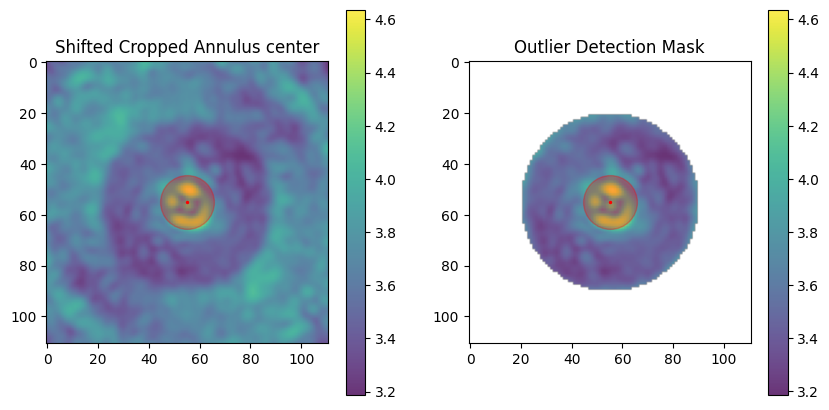

In [23]:
plt.figure(figsize = (10,5))

plt.subplot(121)
plt.imshow(np.log10(crop_ref_shifted), alpha = 0.8)
plt.colorbar()
plt.title('Shifted Cropped Annulus center')
plt.scatter(sub_center_x_shifted, sub_center_y_shifted, 8, 'red', '.')
plt.scatter(sub_center_x_shifted, sub_center_y_shifted, 1500, 'red', 'o', alpha = 0.3)

plt.subplot(122)
plt.imshow(np.log10(crop_ref_shifted * mask_outlier.to_image(crop_ref_shifted.shape)), alpha = 0.8)
plt.colorbar()
plt.title('Outlier Detection Mask')
plt.scatter(sub_center_x_shifted, sub_center_y_shifted, 8, 'red', '.')
plt.scatter(sub_center_x_shifted, sub_center_y_shifted, 1500, 'red', 'o', alpha = 0.3)


## Create the files

In [ ]:
psf_count = 0
diffs_outliers_imgs = {}
# diffs_outliers_psf = {}
raw_contrast_amplitudes = {}
coords = (100,100)


# 0) Save an uncorrelated median psf
    
psf_uncorelated, norm_const_uncorelated = run_pre_processing(img_file = ori_folder + 'psf_', 
                    img_key = 10000, 
                    dark_file = f'{ori_folder}darks_psf',  
                    dark_key= 10000, 
                    ref_psf=f'{ori_folder}psf_', 
                    radius = radius,
                    normalisation=True,
                    method = 'fixed',
                    coords = coords
                    )

psf_med = np.mean(psf_uncorelated, axis = 0)
np.save(f'{save_path}psf_uncorrelated.npy', psf_med)


for i, img_file in enumerate(img_files[:2]):

    # 1) Align, center and crop
    sci_img_processed, norm_const_1 = run_pre_processing(img_file = ori_folder + Path(img_file).stem,
                    img_key = 9986, 
                    dark_file = f'{ori_folder}darks_img',  
                    dark_key= 10000, 
                    ref_psf=f'{ori_folder}psf_', 
                    radius = radius,
                    #method='masked_annulus',
                    normalisation= True,
                    method = 'fixed',
                    coords = coords
                    )

                

    # 2) Sort filename
    name = os.path.basename(img_file)          # int_1.0ro_10ws_no_coro_2026-07-22T11-24-21.543_0
    save_name = name.split("_coro")[0]  # int_1.0ro_10ws_no_coro

    if img_root_counts[save_name] > 1:
        img_counter[save_name] += 1
        filename = f"{save_name}_{img_counter[save_name]}.npy"
    else:
        filename = f"{save_name}.npy"

    # 3) Detect outliers
    sci_img_processed_no_outlier, outlier_matrix, norm_const_2 = run_outlier_detection(img_file = filename.split('.n')[0], 
                        sci_img_processed = sci_img_processed, 
                        n_components=3,
                        mad_threshold=6,
                        PCA_analysis = False,
                        PCA_plot_output= save_plot_path,
                        normalisation = True,
                        mask = mask_outlier
                        )

    # plot_outlier_images_by_pc(
    #     sci_img_processed, outlier_matrix
    #     )
    diff = np.mean(sci_img_processed, axis = 0) - np.mean(sci_img_processed_no_outlier, axis = 0)

    
    # 4) Save the file
    np.save(save_path+filename, sci_img_processed_no_outlier)
    diffs_outliers_imgs[filename.split('.n')[0]] = (diff)
    raw_contrast_amplitudes[filename.split('.n')[0]] = norm_const_1 * norm_const_2 / norm_const_uncorelated * DIT_psf / DIT_img

#for psf_file in psf_files[-2:]:
    # 5) Do the sme if psf corresponds
    # 5.1) Check if need to do psf
    mod = i%3
    if mod != 2:
        psf_file = psf_files[psf_count]
        psf_img_processed, _ = run_pre_processing(img_file = ori_folder + Path(psf_file).stem, 
                            img_key = 10000, 
                            dark_file = f'{ori_folder}darks_psf',  
                            dark_key= 10000, 
                            ref_psf=f'{ori_folder}psf_', 
                            radius = radius,
                            #method='gaussian',
                            normalisation= True,
                            method = 'fixed',
                            coords = coords
                            )
        # 5.2) Detect outliers
        # psf_img_processed_no_outlier, outlier_matrix = run_outlier_detection(img_file = ori_folder + Path(psf_file).stem, 
        #                     sci_img_processed = psf_img_processed, 
        #                     n_components=3,
        #                     mad_threshold=6,
        #                     PCA_analysis = False,
        #                     PCA_plot_output= save_plot_path,
        #                     normalisation= True
        #                     )
        # plot_outlier_images_by_pc(
        #     psf_img_processed, outlier_matrix
        #     )
        # diff = np.mean(psf_img_processed, axis = 0) - np.mean(psf_img_processed_no_outlier, axis = 0)

        
        # 5.3) Save the file
        psf_med = np.mean(psf_img_processed, axis = 0)
        name = os.path.basename(psf_file)          # int_1.0ro_10ws_no_coro_2026-07-22T11-24-21.543_0       
        save_name = name.split("_no")[0]  # int_1.0ro_10ws_no_coro

        if psf_root_counts[save_name] > 1:
            psf_counter[save_name] += 1
            filename = f"psf_{save_name}_{img_counter[save_name]}.npy"
        else:
            filename = f"psf_{save_name}.npy"


        # name = os.path.basename(psf_file)          # int_1.0ro_10ws_no_coro_2026-07-22T11-24-21.543_0
        # save_name = name.split("_no")[0]  # int_1.0ro_10ws_no_coro
        # np.save(f'{save_path}psf_{save_name}.npy', psf_med)
        np.save(save_path+filename, psf_med) 
        # diffs_outliers_psf[filename.split('.n')[0]] = (diff)

        psf_count += 1




KeyboardInterrupt: 

## Run Analysis

/home/aosimul/noah/notebooks/utils/plot_pre_processing.py:856: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  #rect=[0, 0, 1, 0.96]


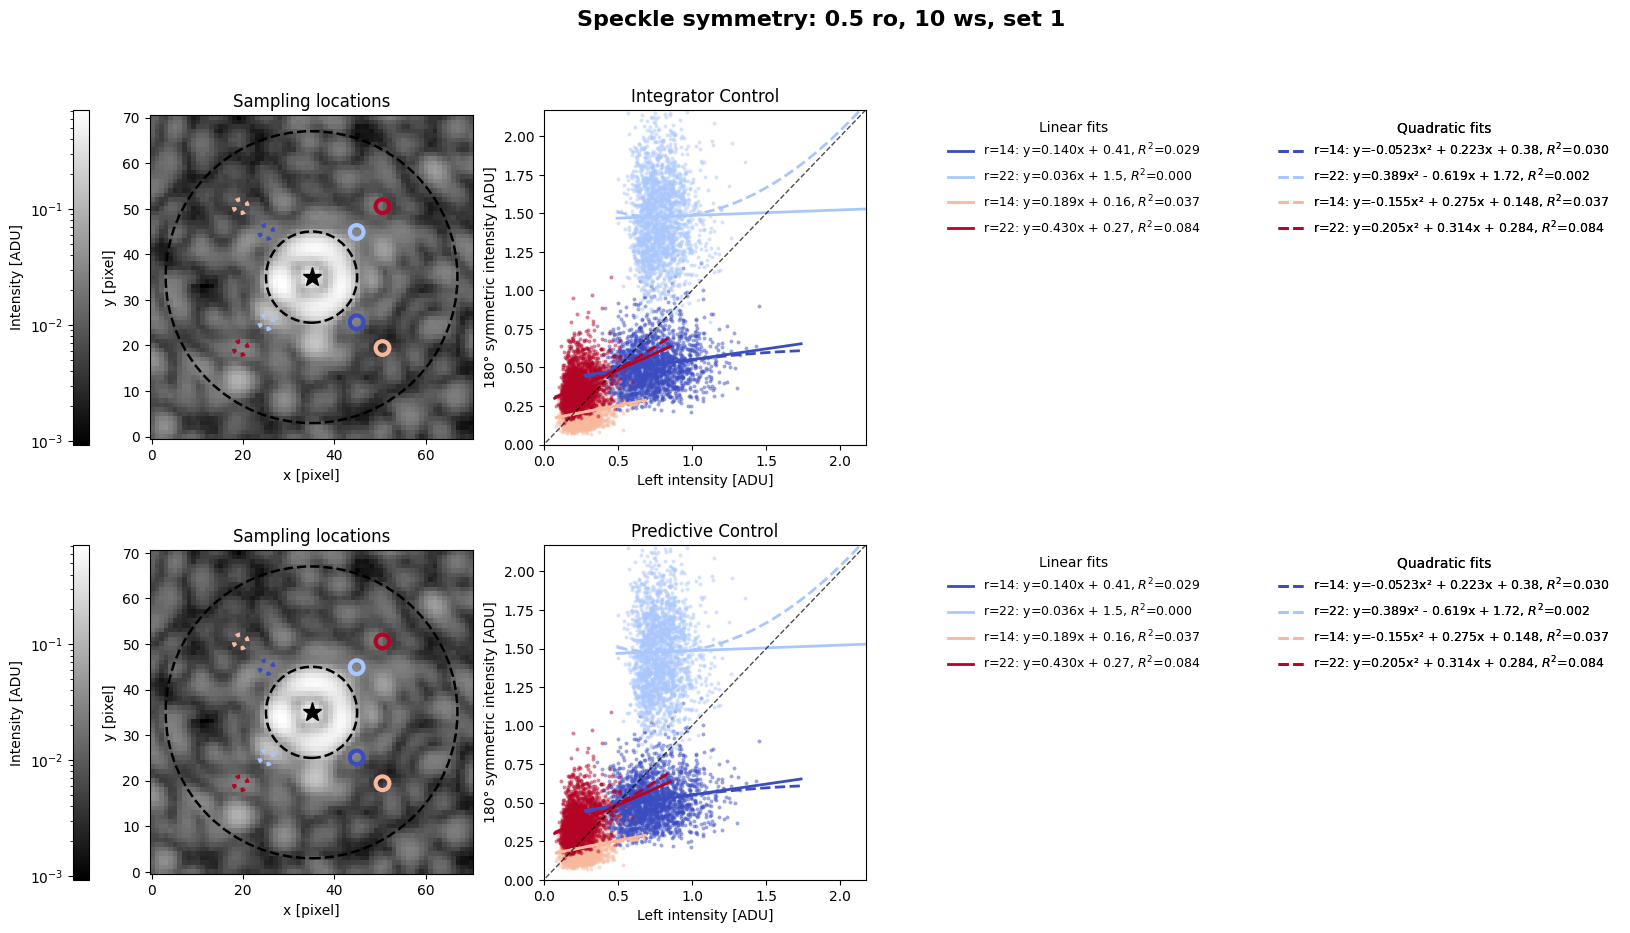

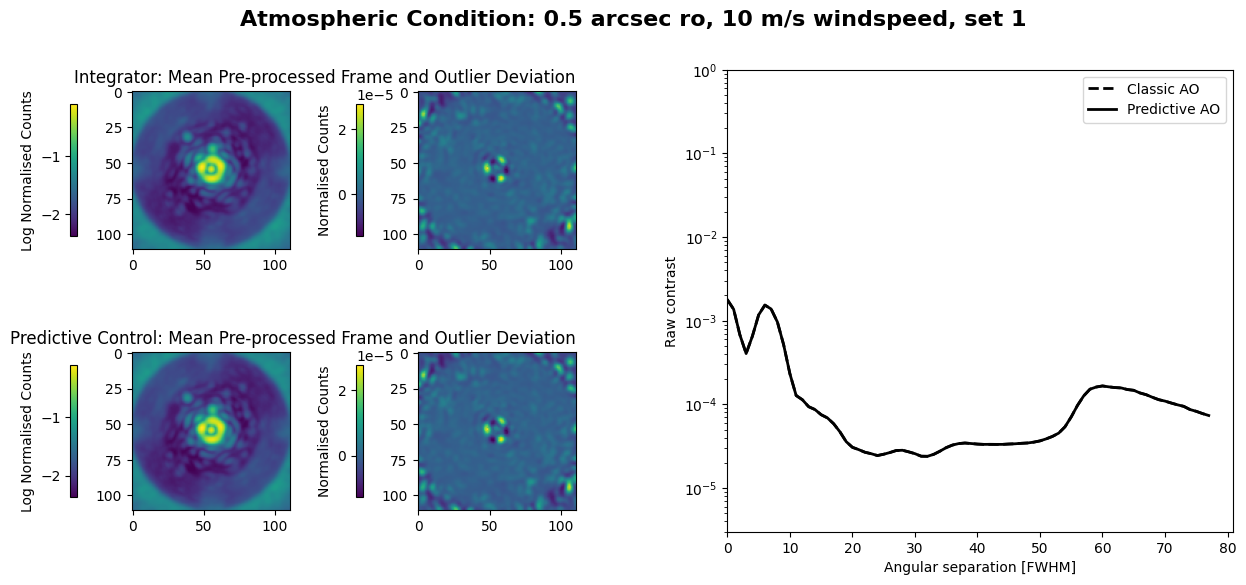

/home/aosimul/noah/notebooks/utils/plot_pre_processing.py:856: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  #rect=[0, 0, 1, 0.96]


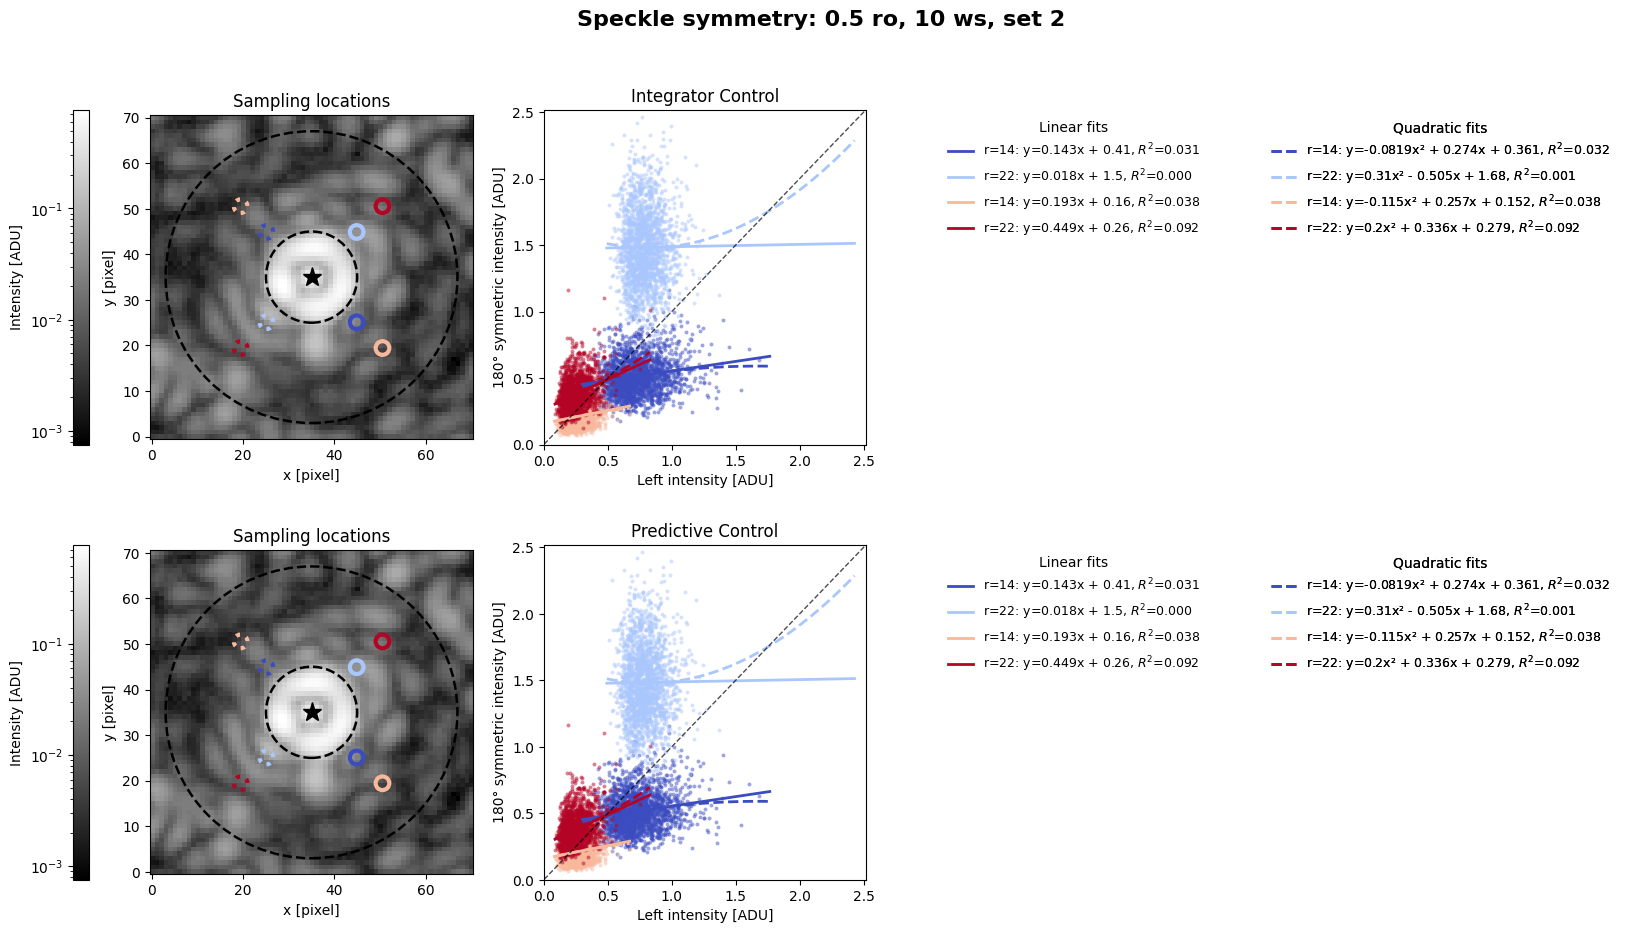

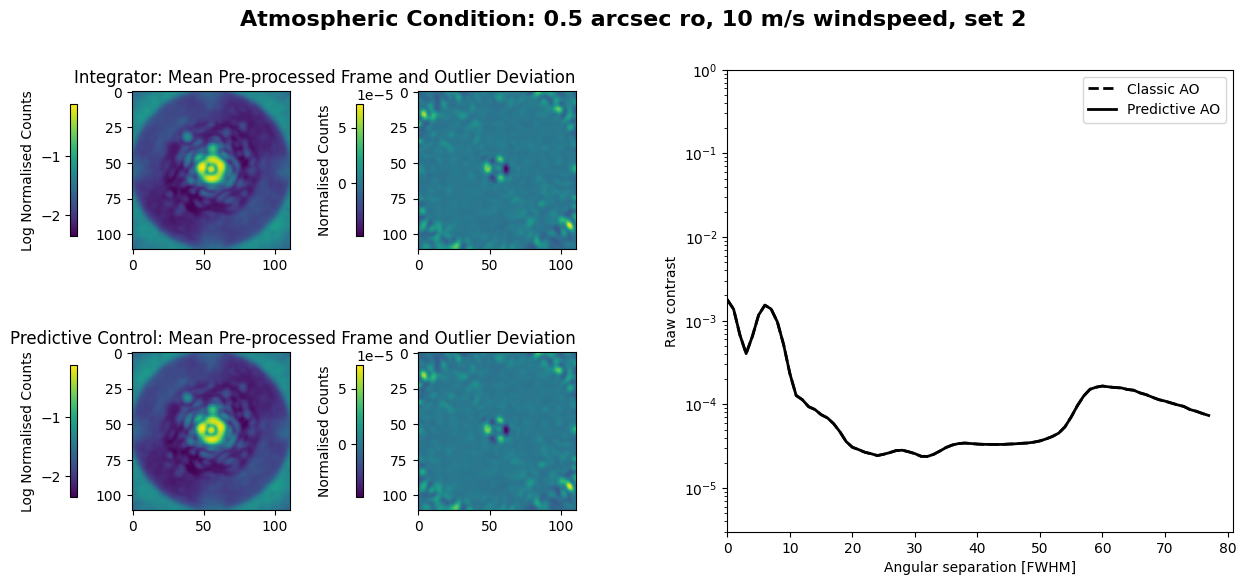

/home/aosimul/noah/notebooks/utils/plot_pre_processing.py:856: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  #rect=[0, 0, 1, 0.96]


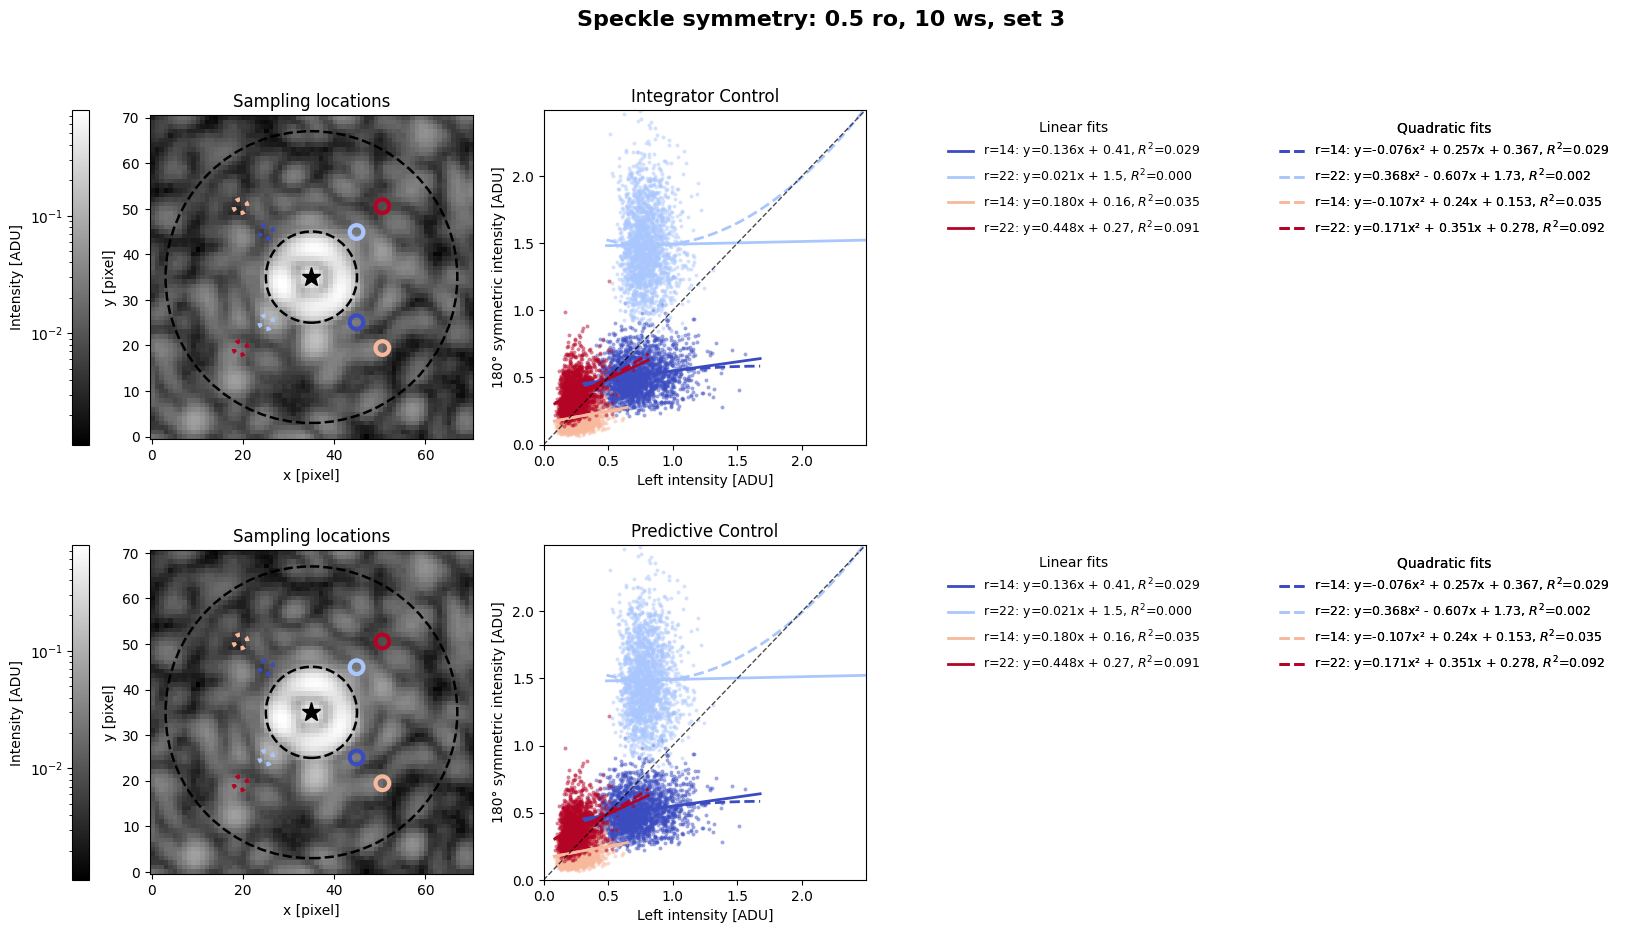

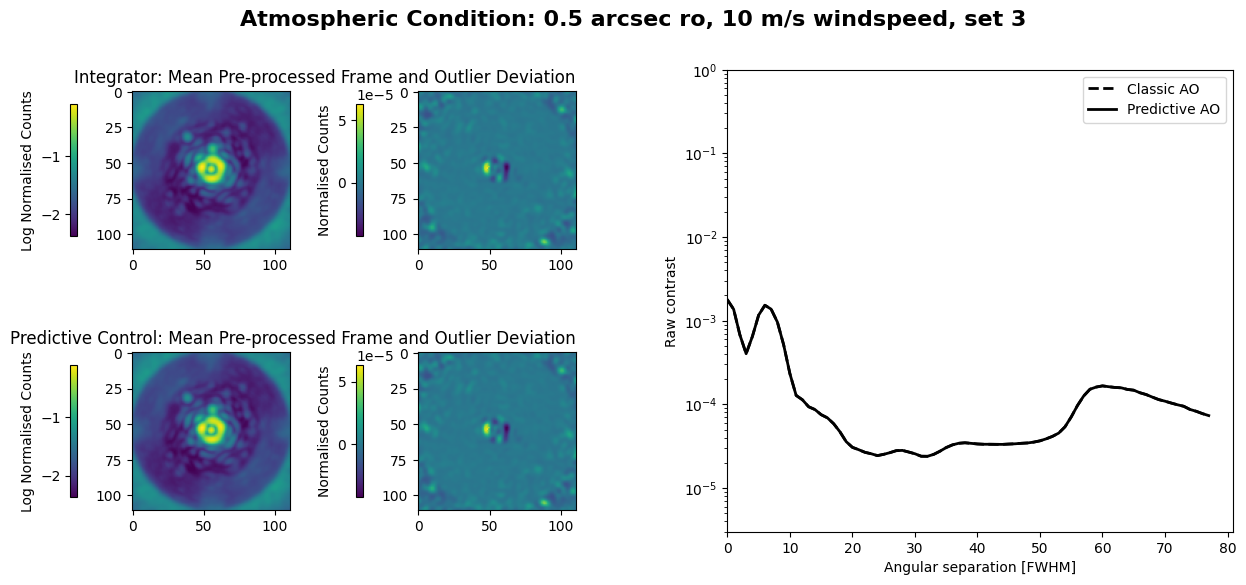

/home/aosimul/noah/notebooks/utils/plot_pre_processing.py:856: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  #rect=[0, 0, 1, 0.96]


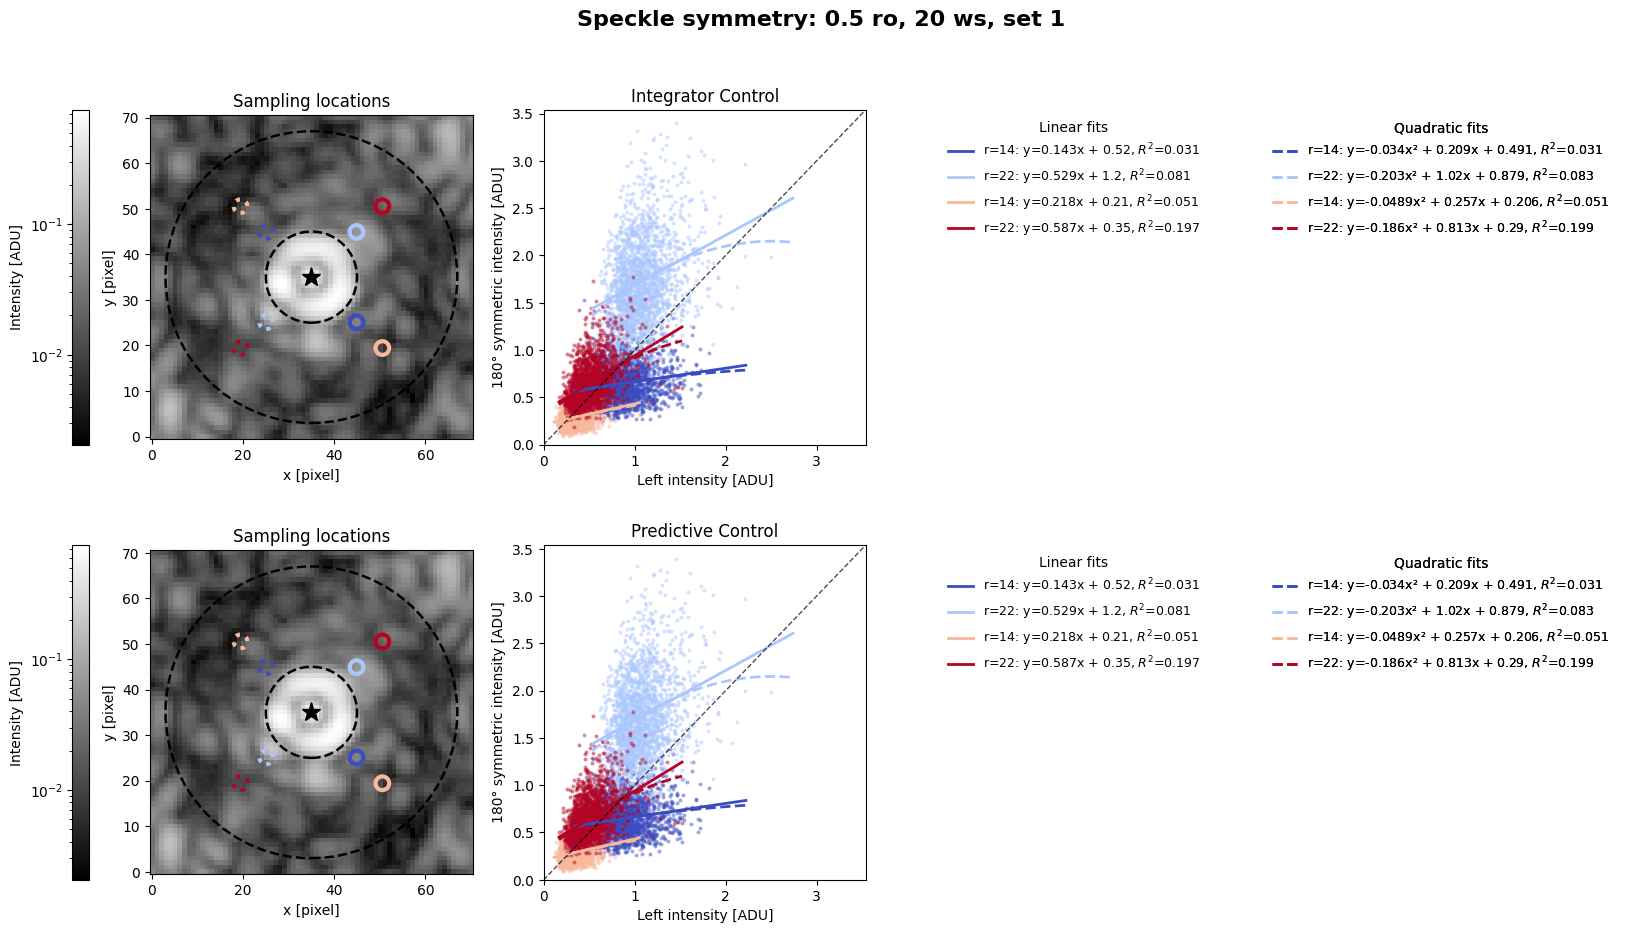

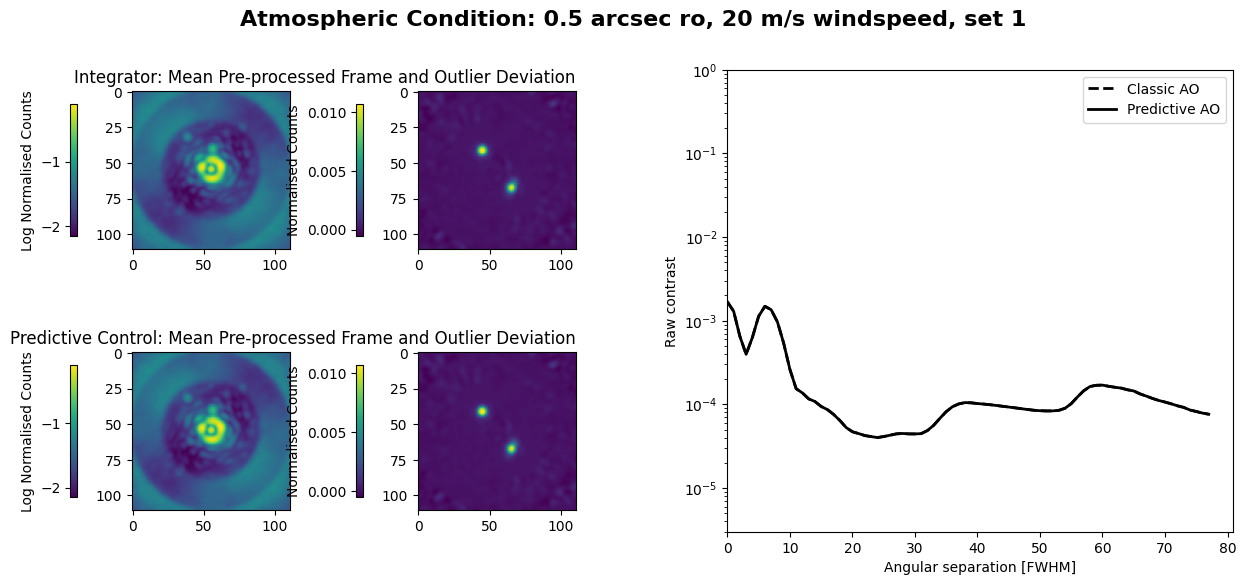

/home/aosimul/noah/notebooks/utils/plot_pre_processing.py:856: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  #rect=[0, 0, 1, 0.96]


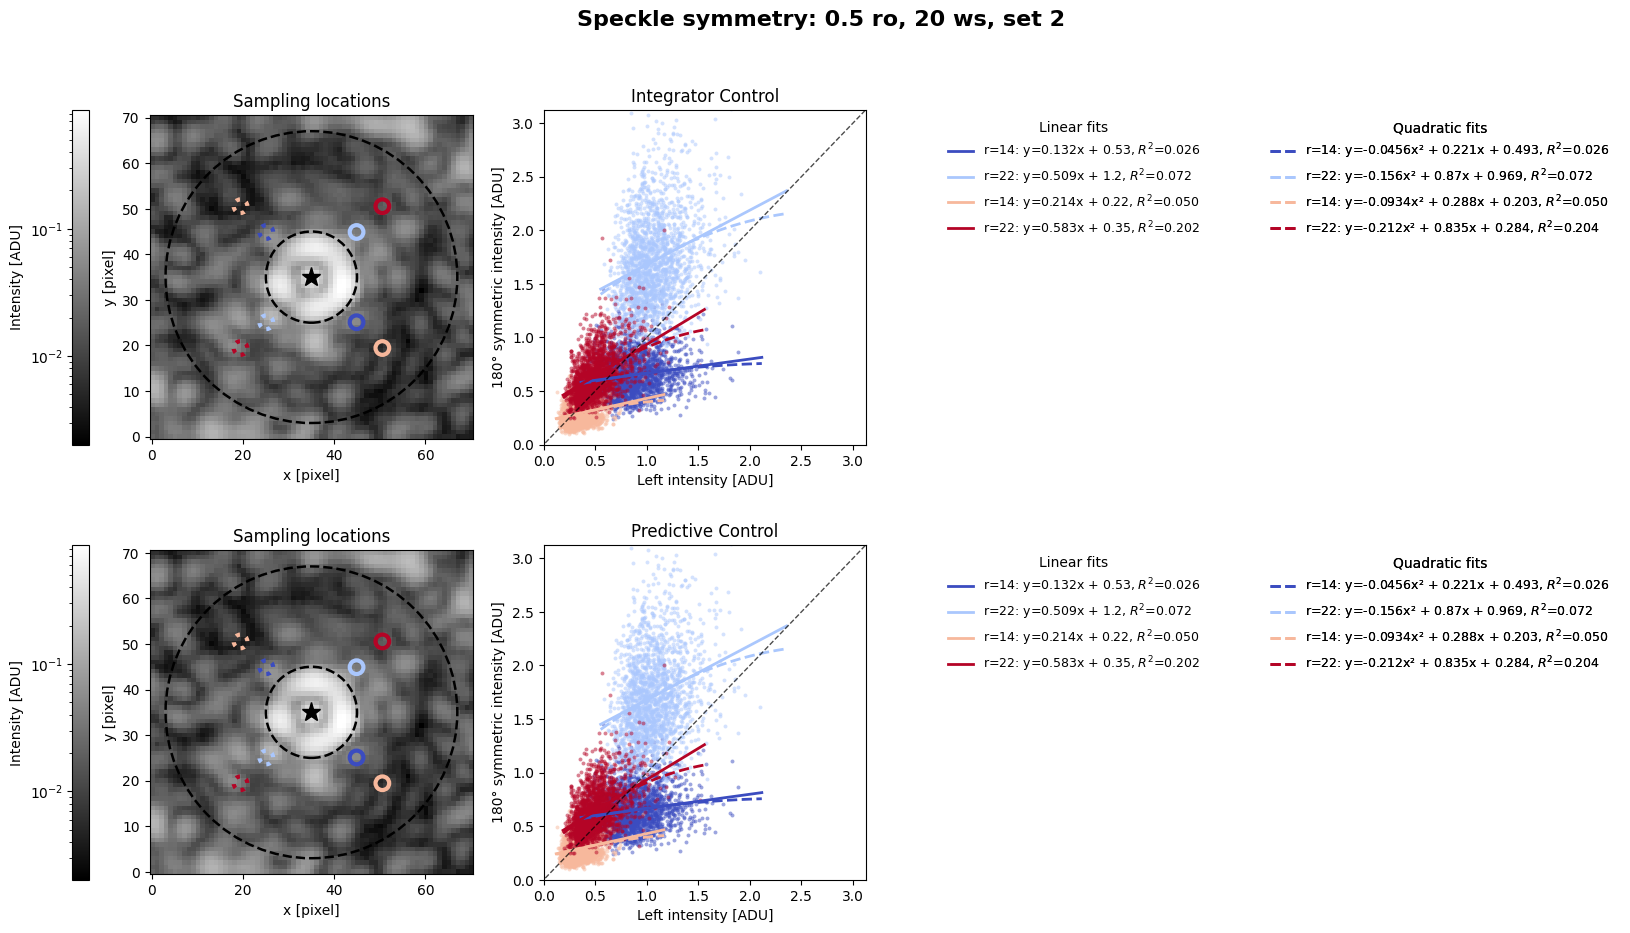

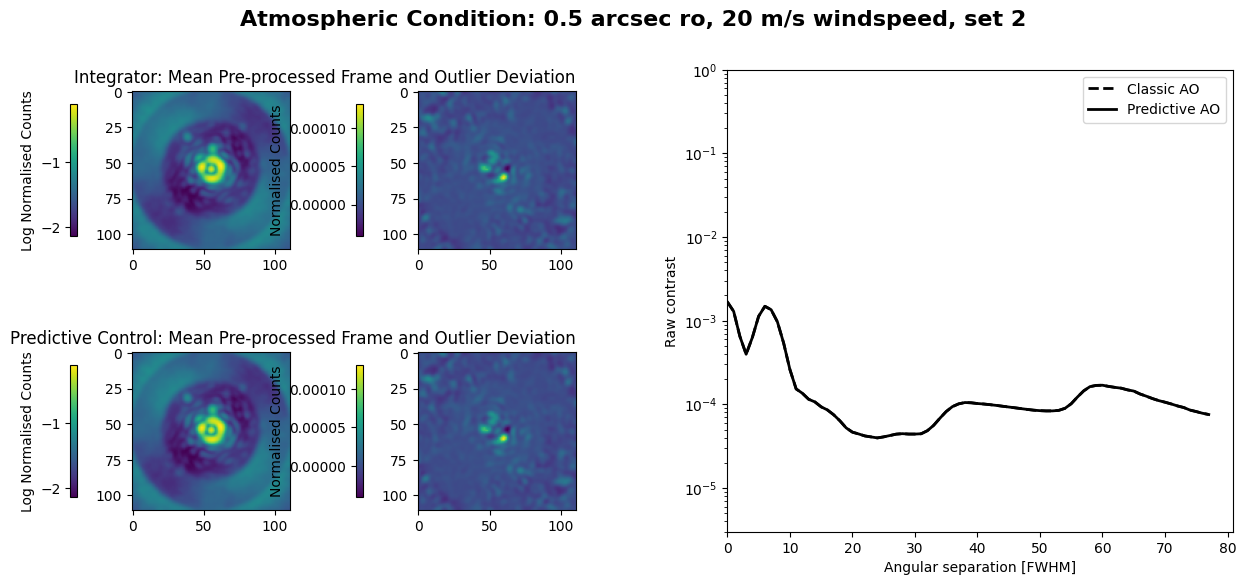

/home/aosimul/noah/notebooks/utils/plot_pre_processing.py:856: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  #rect=[0, 0, 1, 0.96]


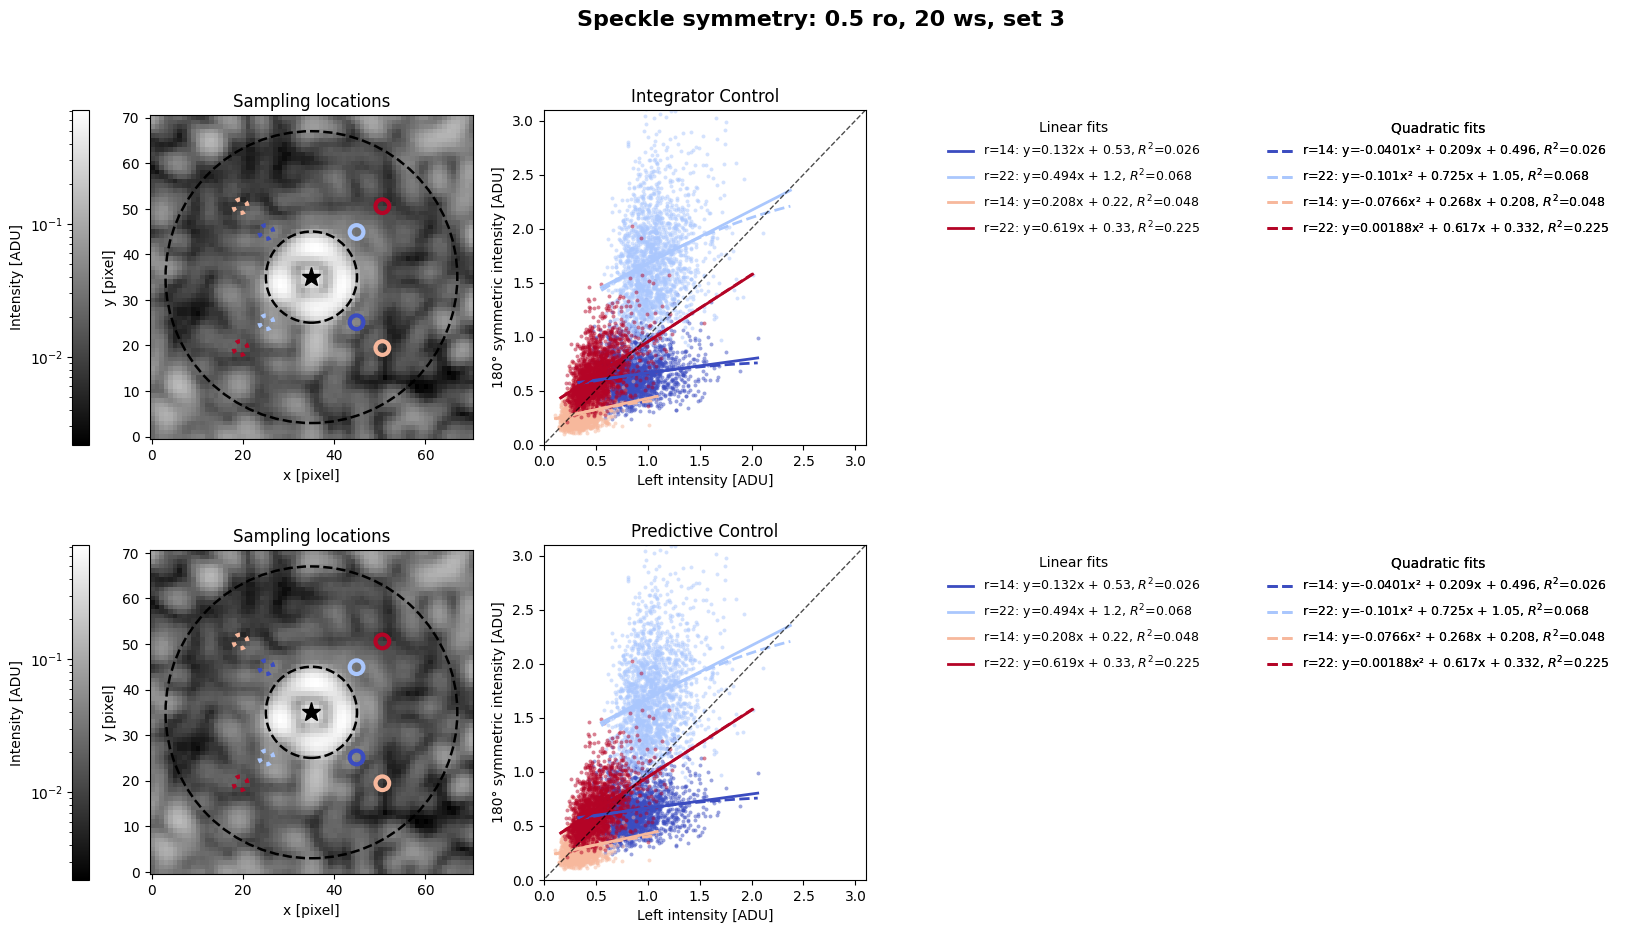

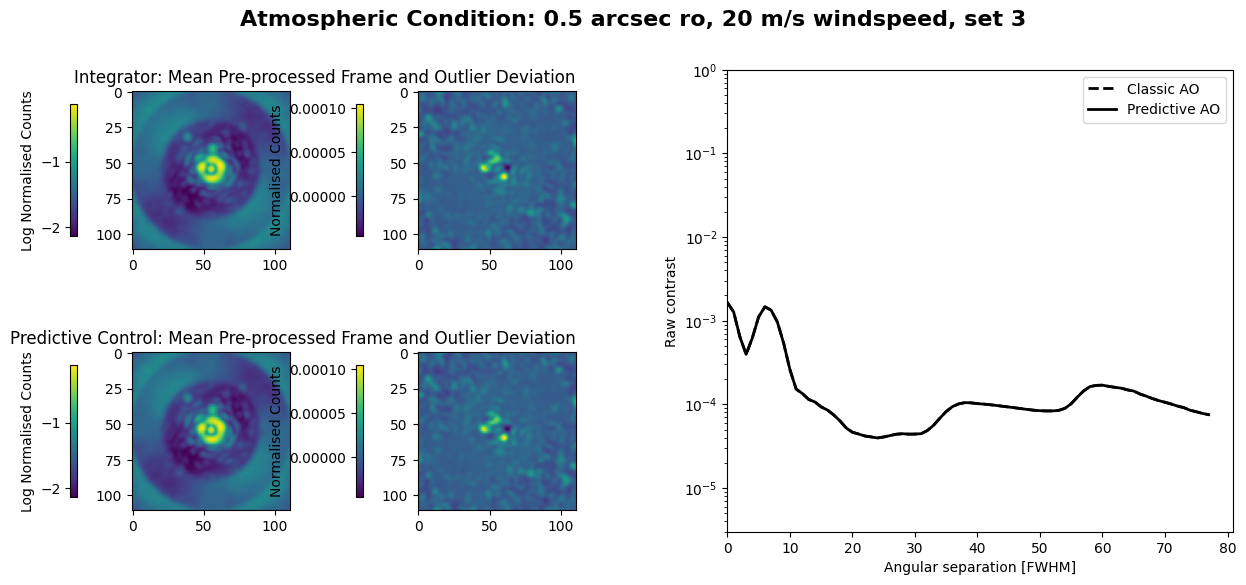

FileNotFoundError: [Errno 2] No such file or directory: '/home/aosimul/noah/data/ghost_images/10_20ws_2/int_0.7ro_10ws_1.npy'

In [54]:
out_path = '/home/aosimul/noah/results/animations/pre_processing/'
ori_path = '/home/aosimul/noah/data/ghost_images/10_20ws_2/'
for ro in [0.5, 0.7, 1.0]: 
    for ws in [10, 20]:
        for count in [1,2,3]: 
            count_psf = count if count <3 else 2
            name = f"{ro}ro_{ws}ws" 

            int_cube = np.load( f"{ori_path}int_{name}_{count}.npy" ) 
            pred_cube = np.load( f"{ori_path}int_{name}_{count}.npy" ) 

            # Speckle Linearity

            fig, fit_results = plot_symmetric_comparison( 
                int_cube, pred_cube, suptitle=f"Speckle symmetry: {ro} ro, {ws} ws, set {count}", angle=[-45.0, 45.0], dr = 2, r_aperture = 3) 
            plt.savefig(f'{out_path}linearity_{name}_{count}.png', dpi=300, bbox_inches="tight")
            plt.show()

            # Outliers and Intensity Contrast


            fig = plt.figure(figsize = (15,6))

            # Main grid: left column narrow, right column wide
            gs = fig.add_gridspec(1, 2, width_ratios=[1,1], wspace=0.3)

            gs_left = gs[0].subgridspec(2, 2, wspace=0.3, hspace = 0.3)

            ax1 = fig.add_subplot(gs_left[0])
            ax2 = fig.add_subplot(gs_left[1])
            ax3 = fig.add_subplot(gs_left[2])
            ax4 = fig.add_subplot(gs_left[3])

            # Right image spans the entire right column
            ax_big = fig.add_subplot(gs[1])

            ax2.set_title('Integrator: Mean Pre-processed Frame and Outlier Deviation', loc = 'right')
            im = ax1.imshow(np.log10(np.mean(int_cube, axis = 0)))
            plt.colorbar(im, label='Log Normalised Counts', fraction =0.03, location = 'left', pad = 0.25)

            ax2.set_title(' ')
            im = ax2.imshow((diffs_outliers_imgs[f'int_{name}_{count}']))
            plt.colorbar(im, label='Normalised Counts', fraction =0.03, location = 'left', pad = 0.25)

            ax_big.set_title(' ')
            r_int, y_noncoro_int, _ = radial_profile_pre(np.mean(int_cube, axis = 0))
            r_pred, y_noncoro_pred, _ = radial_profile_pre(np.mean(pred_cube, axis = 0))
            ax_big.plot(r_int, y_noncoro_int * raw_contrast_amplitudes[f'int_{name}_{count}'], '--', color = 'k', lw = 2, label = 'Classic AO')
            ax_big.plot(r_pred, y_noncoro_pred * raw_contrast_amplitudes[f'int_{name}_{count}'], '-', color = 'k', lw = 2, label = 'Predictive AO')
            ax_big.legend()
            ax_big.set_yscale('log')
            ax_big.set_xlim(left =0)
            ax_big.set_ylim(3e-6, 1)
            ax_big.set_xlabel("Angular separation [FWHM]")
            ax_big.set_ylabel("Raw contrast")

            ax4.set_title('Predictive Control: Mean Pre-processed Frame and Outlier Deviation', loc = 'right')
            im = ax3.imshow(np.log10(np.mean(pred_cube, axis = 0)))
            plt.colorbar(im, label='Log Normalised Counts', fraction =0.03, location = 'left', pad = 0.25)

            ax4.set_title(' ')
            im = ax4.imshow((diffs_outliers_imgs[f'int_{name}_{count}']))
            plt.colorbar(im, label='Normalised Counts', fraction =0.03, location = 'left', pad = 0.25)

            plt.suptitle(f'Atmospheric Condition: {ro} arcsec ro, {ws} m/s windspeed, set {count}', fontweight = 'bold', fontsize = 16)
            
            plt.savefig(f'{out_path}raw_contrast_{name}_{count}.png', dpi=300, bbox_inches="tight")
            plt.show()
            
